## IMPORT

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import math
import lightgbm as lgb
import seaborn as sns
import joblib as jbl
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, confusion_matrix

## PRE PROCESSING

In [3]:
df = pd.read_parquet("US_accidents_dataset.parquet")
df.drop(columns=["Turning_Loop", "End_Lat", "End_Lng", "Airport_Code"], inplace=True)

df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')
df['End_Time']   = pd.to_datetime(df['End_Time'],   format='mixed')
df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
df['hour']  = df['Start_Time'].dt.hour
df['month'] = df['Start_Time'].dt.month

def is_us_holiday(dt):
    m, d = dt.month, dt.day
    if (m == 12 and d >= 24) or (m == 1 and d <= 2): return 1
    if m == 11 and d >= 22:      return 1
    if m == 7  and d == 4:       return 1
    if m == 5  and d >= 25:      return 1
    if m == 9  and d <= 7:       return 1
    if m == 10 and d == 31:      return 1
    if m == 2  and 7 <= d <= 10: return 1
    return 0

df['is_holiday_period'] = df['Start_Time'].apply(is_us_holiday)
df.drop(columns=['Start_Time', 'End_Time', 'Weather_Timestamp'], inplace=True)
df.drop(columns=['Wind_Chill(F)', 'Country'], inplace=True)

def time_of_day(h):
    if 6  <= h < 9:  return 0  # morning_rush
    if 9  <= h < 16: return 1  # daytime
    if 16 <= h < 19: return 2  # evening_rush
    if 19 <= h < 23: return 3  # evening
    return 4                   # night

df['time_of_day'] = df['hour'].apply(time_of_day)

# Encoding ciclico mese
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df.drop(columns=['hour', 'month'], inplace=True)

def group_weather(w):
    if pd.isna(w): return 'Unknown'
    w = str(w).lower()
    if any(x in w for x in ['thunder', 't-storm', 'thunderstorm', 'tornado', 'funnel']): return 'Storm'
    if any(x in w for x in ['snow', 'blizzard', 'wintry', 'sleet', 'ice pellet', 'snow grain', 'freezing', 'hail']): return 'Snow_Ice'
    if any(x in w for x in ['heavy rain', 'rain shower', 'rain', 'drizzle', 'shower']): return 'Rain'
    if any(x in w for x in ['fog', 'mist', 'haze']):                                    return 'Fog_Low_Visibility'
    if any(x in w for x in ['smoke', 'dust', 'sand', 'ash', 'squall']):                 return 'Dust_Smoke'
    if any(x in w for x in ['cloud', 'overcast', 'scattered', 'mostly', 'partly']):     return 'Cloudy'
    if any(x in w for x in ['clear', 'fair', 'sunny']):                                 return 'Clear'
    return 'Other'

def weather_intensity(w):
    if pd.isna(w): return np.nan
    w = str(w).lower()
    if any(x in w for x in ['heavy', 'severe', 'tornado', 'funnel', 'blizzard', 'duststorm']): return 3
    if any(x in w for x in ['moderate', 'thunder', 't-storm', 'squall', 'wintry mix']):         return 2
    if any(x in w for x in ['light', 'drizzle', 'mist', 'shallow', 'partial', 'patches']):      return 1
    return 0

df['Weather_Group']     = df['Weather_Condition'].apply(group_weather)
df['Weather_Intensity'] = df['Weather_Condition'].apply(weather_intensity)
df.drop(columns=['Weather_Condition'], inplace=True)

def classify_street(name):
    if pd.isna(name): return 'Unknown'
    name_upper = str(name).upper().strip()
    name_clean = re.sub(r'\s+(N|S|E|W|NE|NW|SE|SW)$', '', name_upper).strip()
    if re.match(r'^I-\d+', name_clean):          return 'Interstate'
    if re.match(r'^US-\d+', name_clean):         return 'US_Route'
    if re.match(r'^[A-Z]{2}-\d+', name_clean):  return 'State_Route'
    if any(x in name_clean for x in ['FWY', 'FREEWAY', 'EXPRESSWAY', 'EXPY', 'TPKE', 'TURNPIKE', 'PIKE']): return 'Freeway_Expressway'
    if any(x in name_clean for x in ['HWY', 'HIGHWAY']):    return 'Highway'
    if any(x in name_clean for x in ['PKWY', 'PARKWAY']):   return 'Parkway'
    if any(x in name_clean for x in ['BLVD', 'BOULEVARD']): return 'Boulevard'
    if any(x in name_clean for x in [' AVE', 'AVENUE']):    return 'Avenue'
    if any(x in name_clean for x in [' RD', ' ROAD']):      return 'Road'
    if any(x in name_clean for x in [' ST', ' STREET']):    return 'Street'
    if any(x in name_clean for x in [' DR', ' DRIVE']):     return 'Drive'
    if any(x in name_clean for x in [' LN', ' LANE']):      return 'Lane'
    if any(x in name_clean for x in [' TRL', ' TRAIL']):    return 'Trail'
    if any(x in name_clean for x in [' CT', ' COURT', ' CIR', ' CIRCLE', ' PL', ' PLACE', ' WAY']): return 'Local'
    return 'Other'

df['Street_Type'] = df['Street'].apply(classify_street)
df.drop(columns=['Street'], inplace=True)

df.drop(columns=['ID'], inplace=True)
df['desc_length']         = df['Description'].str.len()
df['lanes_blocked']       = df['Description'].str.extract(r'(\d+)\s+lane', expand=False).fillna(0).astype(int)
df['mentions_closed']     = df['Description'].str.contains(r'closed|closure',         case=False, na=False).astype(int)
df['mentions_blocked']    = df['Description'].str.contains(r'blocked',                case=False, na=False).astype(int)
df['mentions_stationary'] = df['Description'].str.contains(r'stationary traffic',     case=False, na=False).astype(int)
df['mentions_slow']       = df['Description'].str.contains(r'slow traffic',           case=False, na=False).astype(int)
df['mentions_delay']      = df['Description'].str.contains(r'delay|expect delay',     case=False, na=False).astype(int)
df['mentions_shoulder']   = df['Description'].str.contains(r'shoulder',               case=False, na=False).astype(int)
df['unconfirmed']         = df['Description'].str.contains(r'unconfirmed',            case=False, na=False).astype(int)
df['multiple_vehicles']   = df['Description'].str.contains(r'\d+\s*veh|multiple veh', case=False, na=False).astype(int)
df['desc_highway']        = df['Description'].str.contains(r'I-\d+|interstate|freeway|fwy|pkwy|expy', case=False, na=False).astype(int)
df['drive_caution']       = df['Description'].str.contains(r'drive with caution|use caution', case=False, na=False).astype(int)
df['crash_confirmed']     = df['Description'].str.contains(r'crash|accident',         case=False, na=False).astype(int)
df.drop(columns=['Description'], inplace=True)

bool_cols = ['Amenity','Bump','Crossing','Give_Way','Junction',
             'No_Exit','Railway','Roundabout','Station','Stop',
             'Traffic_Calming','Traffic_Signal']
df[bool_cols] = df[bool_cols].astype(int)

df['Sunrise_Sunset'] = (df['Sunrise_Sunset'] == 'Day').astype(int)
df.drop(columns=['Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight'], inplace=True)

direction_map = {
    'N': 0, 'NNE': 22.5, 'NE': 45, 'ENE': 67.5,
    'E': 90, 'ESE': 112.5, 'SE': 135, 'SSE': 157.5,
    'S': 180, 'SSW': 202.5, 'SW': 225, 'WSW': 247.5,
    'W': 270, 'WNW': 292.5, 'NW': 315, 'NNW': 337.5,
    'Calm': -1, 'VAR': -1, 'Variable': -1
}
df['Wind_Deg']  = df['Wind_Direction'].map(direction_map)
df['Wind_Sin']  = np.where(df['Wind_Deg'] >= 0, np.sin(np.radians(df['Wind_Deg'])), 0)
df['Wind_Cos']  = np.where(df['Wind_Deg'] >= 0, np.cos(np.radians(df['Wind_Deg'])), 0)
df['Wind_Calm'] = (df['Wind_Deg'] < 0).astype(int)
df.drop(columns=['Wind_Direction', 'Wind_Deg'], inplace=True)

source_map = {'Source1': 0, 'Source2': 1, 'Source3': 2}
df['Source'] = df['Source'].map(source_map)

df.drop(columns=[
    'Roundabout', 'Bump', 'Traffic_Calming', 'No_Exit',
    'unconfirmed', 'Amenity', 'Railway', 'Give_Way',
    'multiple_vehicles', 'Station', 'Weather_Windy', 'Timezone'
], inplace=True, errors='ignore')

cols_to_log = ['duration_min', 'Distance(mi)', 'Wind_Speed(mph)', 'desc_length']
for col in cols_to_log:
    df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
    df.drop(columns=[col], inplace=True)

df['Distance(mi)_log'] = np.log1p(df['Distance(mi)_log'])

if 'Precipitation(in)' in df.columns:
    df['is_raining'] = (df['Precipitation(in)'] > 0).astype(int)
    df.drop(columns=['Precipitation(in)'], inplace=True)

for col in ['Weather_Group', 'Street_Type']:
    df[col] = df[col].astype('category')

print(f"Shape dopo preprocessing: {df.shape}")
print(f"NaN rimasti: {df.isnull().sum().sum()}")

Shape dopo preprocessing: (7728394, 42)
NaN rimasti: 1402639


## SPLIT

In [4]:
X = df.drop(columns=['Severity'])
y = df['Severity'] - 1  # classi 0,1,2,3

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

km = KMeans(n_clusters=10, random_state=42, n_init=10)
km.fit(X_train[['Start_Lat', 'Start_Lng']].sample(200000, random_state=42))

X_train = X_train.copy()
X_val   = X_val.copy()
X_test  = X_test.copy()

X_train['Geo_Cluster'] = km.predict(X_train[['Start_Lat', 'Start_Lng']])
X_val['Geo_Cluster']   = km.predict(X_val[['Start_Lat', 'Start_Lng']])
X_test['Geo_Cluster']  = km.predict(X_test[['Start_Lat', 'Start_Lng']])

# ← AGGIUNGI QUI il frequency encoding
for col in ['City', 'County', 'State', 'Zipcode']:
    if col in X_train.columns:
        freq         = X_train[col].value_counts()
        X_train[col] = X_train[col].map(freq)
        X_val[col]   = X_val[col].map(freq).fillna(0)
        X_test[col]  = X_test[col].map(freq).fillna(0)

# ← POI crea le due versioni
X_train_lgb = X_train.copy()
X_val_lgb   = X_val.copy()
X_test_lgb  = X_test.copy()

for col in ['Weather_Group', 'Street_Type', 'Geo_Cluster', 'Source']:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_val_lgb[col]   = X_val_lgb[col].astype('category')
    X_test_lgb[col]  = X_test_lgb[col].astype('category')

Train: (4946172, 41)
Val:   (1236543, 41)
Test:  (1545679, 41)


## LIGHTGBM

In [5]:
model_lgb = jbl.load('lgbm_model_final.pkl')

In [6]:
print("Calcolo probabilità LightGBM su val set...")
lgb_val_probs = model_lgb.predict_proba(X_val_lgb)
jbl.dump(lgb_val_probs, 'lgb_val_probs.pkl')
print(f"Val probs salvate! Shape: {lgb_val_probs.shape}")

Calcolo probabilità LightGBM su val set...
Val probs salvate! Shape: (1236543, 4)


In [7]:
print("\nCalcolo probabilità LightGBM...")
lgb_probs = []
for i in range(0, len(X_test_lgb), 100000):
    batch = X_test_lgb.iloc[i:i+100000]
    lgb_probs.append(model_lgb.predict_proba(batch))
    print(f"LGB Batch {i//100000 + 1}/{math.ceil(len(X_test_lgb)/100000)} completato")
lgb_probs = np.concatenate(lgb_probs)

jbl.dump(lgb_probs, 'lgb_test_probs.pkl')
print(f"Test probs salvate! Shape: {lgb_probs.shape}")


Calcolo probabilità LightGBM...
LGB Batch 1/16 completato
LGB Batch 2/16 completato
LGB Batch 3/16 completato
LGB Batch 4/16 completato
LGB Batch 5/16 completato
LGB Batch 6/16 completato
LGB Batch 7/16 completato
LGB Batch 8/16 completato
LGB Batch 9/16 completato
LGB Batch 10/16 completato
LGB Batch 11/16 completato
LGB Batch 12/16 completato
LGB Batch 13/16 completato
LGB Batch 14/16 completato
LGB Batch 15/16 completato
LGB Batch 16/16 completato
Test probs salvate! Shape: (1545679, 4)


In [8]:
del model_lgb
gc.collect()

36

## RESEARCH BEST WEIGHTS

In [5]:
lgb_test_probs = jbl.load('lgb_test_probs.pkl')
lgb_val_probs  = jbl.load('lgb_val_probs.pkl')
cat_test_probs = jbl.load('cat_test_probs_1.pkl')
cat_val_probs  = jbl.load('cat_val_probs.pkl')

print(f"lgb_test_probs shape: {lgb_test_probs.shape}")
print(f"lgb_val_probs shape:  {lgb_val_probs.shape}")
print(f"cat_test_probs shape: {cat_test_probs.shape}")
print(f"cat_val_probs shape:  {cat_val_probs.shape}")

lgb_test_probs shape: (1545679, 4)
lgb_val_probs shape:  (1236543, 4)
cat_test_probs shape: (1545679, 4)
cat_val_probs shape:  (1236543, 4)


In [6]:
from sklearn.metrics import f1_score

# Ottimizza pesi sul val set
best_f1    = 0
best_w_lgb = 0

for w_lgb in np.arange(0.1, 1.0, 0.1):
    w_cat          = 1 - w_lgb
    ensemble_probs = w_lgb * lgb_val_probs + w_cat * cat_val_probs
    ensemble_preds = ensemble_probs.argmax(axis=1)
    f1             = f1_score(y_val, ensemble_preds, average='macro')
    print(f"LGB={w_lgb:.1f} CAT={w_cat:.1f} → Val F1: {f1:.4f}")

    if f1 > best_f1:
        best_f1    = f1
        best_w_lgb = w_lgb

print(f"\nMiglior combinazione: LGB={best_w_lgb:.1f} CAT={1-best_w_lgb:.1f}")

# Predizioni finali sul test
ensemble_probs_best = best_w_lgb * lgb_test_probs + (1 - best_w_lgb) * cat_test_probs
ensemble_preds_best = ensemble_probs_best.argmax(axis=1)

LGB=0.1 CAT=0.9 → Val F1: 0.7902
LGB=0.2 CAT=0.8 → Val F1: 0.7933
LGB=0.3 CAT=0.7 → Val F1: 0.7960
LGB=0.4 CAT=0.6 → Val F1: 0.7988
LGB=0.5 CAT=0.5 → Val F1: 0.8008
LGB=0.6 CAT=0.4 → Val F1: 0.8016
LGB=0.7 CAT=0.3 → Val F1: 0.8023
LGB=0.8 CAT=0.2 → Val F1: 0.8027
LGB=0.9 CAT=0.1 → Val F1: 0.8033

Miglior combinazione: LGB=0.9 CAT=0.1


## FINAL PREDICTION

In [7]:
ensemble_probs_best = best_w_lgb * lgb_test_probs + (1 - best_w_lgb) * cat_test_probs
ensemble_preds_best = ensemble_probs_best.argmax(axis=1)

print("\n" + "="*60)
print("CLASSIFICATION REPORT - ENSEMBLE FINALE")
print("="*60)
print(classification_report(y_test, ensemble_preds_best,
      target_names=['Severity 1','Severity 2','Severity 3','Severity 4']))


CLASSIFICATION REPORT - ENSEMBLE FINALE
              precision    recall  f1-score   support

  Severity 1       0.75      0.63      0.68     13473
  Severity 2       0.97      0.95      0.96   1231396
  Severity 3       0.85      0.90      0.88    259868
  Severity 4       0.65      0.76      0.70     40942

    accuracy                           0.94   1545679
   macro avg       0.80      0.81      0.80   1545679
weighted avg       0.94      0.94      0.94   1545679



## CONFUSION MATRIX

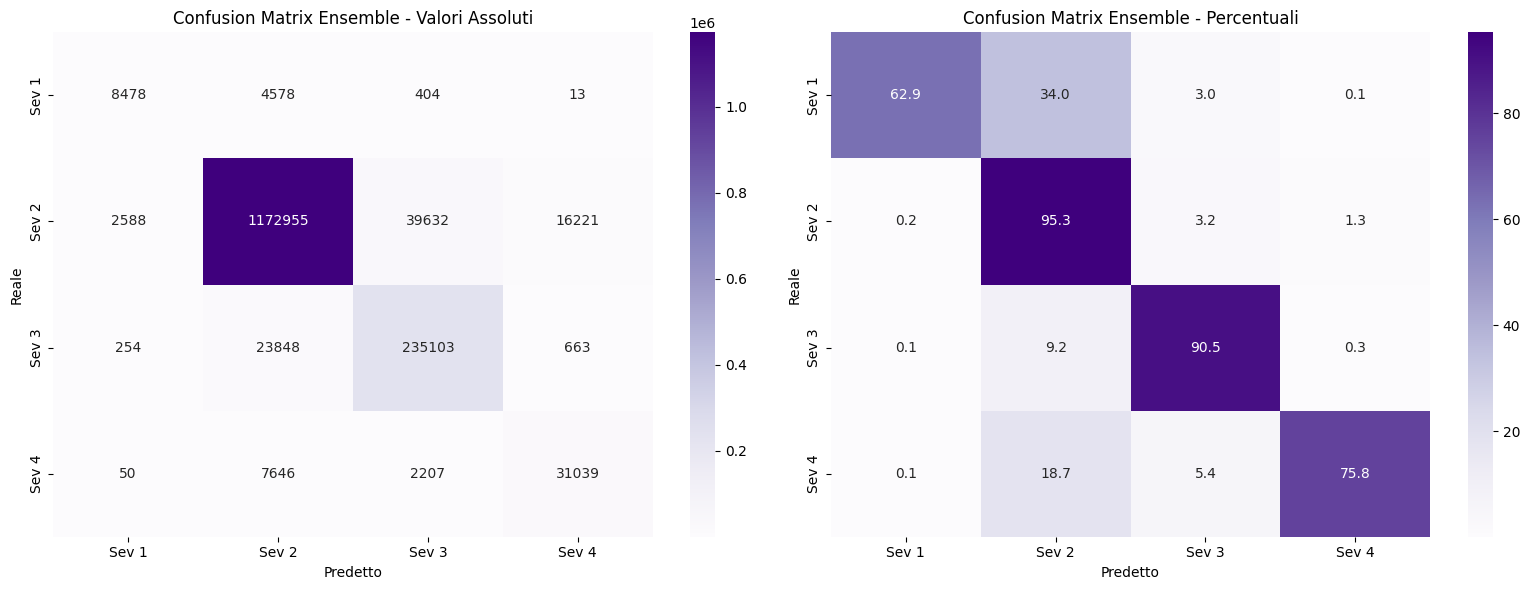

            feature    importance
       Pressure(in) 633211.472747
   duration_min_log 620004.021955
    desc_length_log 618615.304517
            Zipcode 554428.532241
     Temperature(F) 551456.215178
        Humidity(%) 549008.676608
          Start_Lat 491781.407758
          Start_Lng 455665.351406
               City 436259.864722
Wind_Speed(mph)_log 389415.285114
   Distance(mi)_log 364850.756817
             County 355708.539039
           Wind_Cos 210839.026569
          month_sin 189989.718636
           Wind_Sin 189315.064564
          month_cos 178387.426262
              State 170003.015057
        time_of_day 148578.519091
        Street_Type 130192.941071
     Visibility(mi) 107748.474274


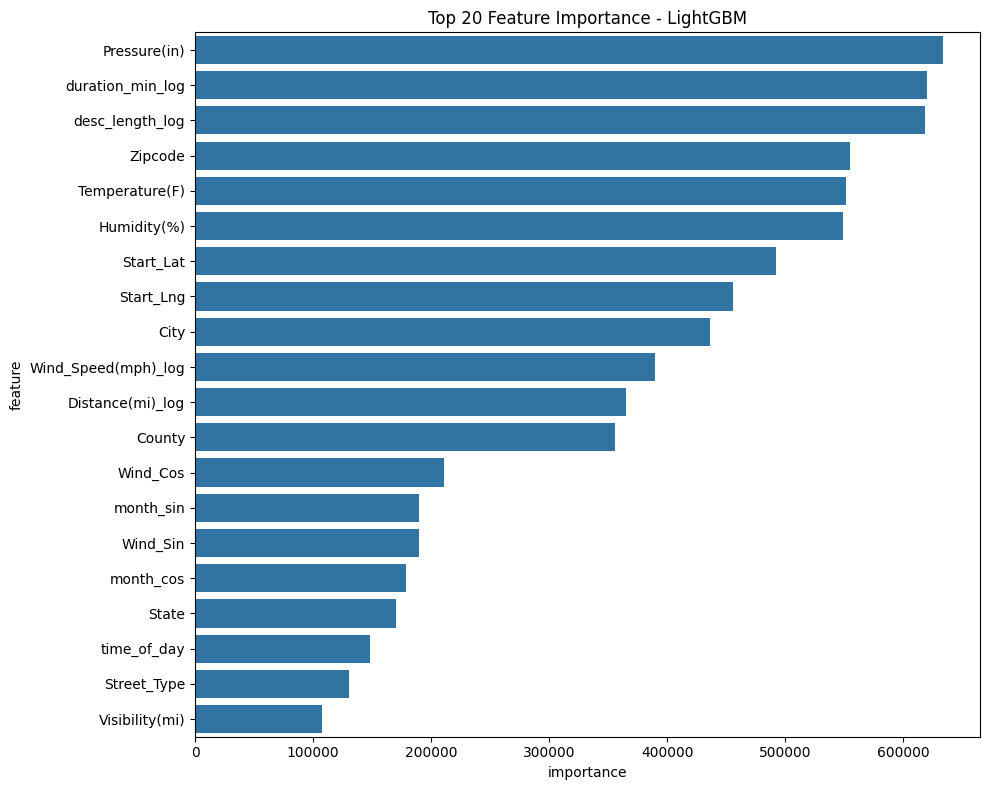

In [8]:
cm         = confusion_matrix(y_test, ensemble_preds_best)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix Ensemble - Valori Assoluti')
axes[0].set_ylabel('Reale')
axes[0].set_xlabel('Predetto')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Purples',
            xticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            yticklabels=['Sev 1','Sev 2','Sev 3','Sev 4'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix Ensemble - Percentuali')
axes[1].set_ylabel('Reale')
axes[1].set_xlabel('Predetto')

plt.tight_layout()
plt.show()

model1 = jbl.load('lgbm_model_final.pkl')
model2 = jbl.load('catboost_model_final_3.pkl')

imp1 = model1.feature_importances_
imp2 = model2.feature_importances_
# media semplice (o pesata se hai pesi diversi)
ensemble_importance = (imp1*0.9 + imp2*0.1) / 2
# tabella ordinata
feat_imp = pd.DataFrame({
    "feature": X_test.columns,
    "importance": ensemble_importance
}).sort_values("importance", ascending=False)

print(feat_imp.head(20).to_string(index=False))

plt.figure(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature')
plt.title('Top 20 Feature Importance - LightGBM')
plt.tight_layout()
plt.show()